# Analysis of JOSS Dependencies

This notebook analyzes the dependencies of projects submitted to the Journal of Open Source Software (JOSS), based on the `joss_all_language_depends.csv` dataset.

In [ ]:
import pandas as pd

# Load the dataset
try:
    df = pd.read_csv('joss_all_language_depends.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'joss_all_language_depends.csv' not found. Please make sure the file is in the correct directory.")

# Display the first few rows of the dataframe
if 'df' in locals():
    display(df.head())

Dataset loaded successfully.


,status,paper_url,issue_url,doi,joss_id,title,html_url,Repository Name,Full Name,Description,...,Created Date,Updated Date,Pushed Date,Default Branch,Size,Contributors,Number of Contributors,Total Downloads,requirements_defined,dependecies_found
0,published,https://joss.theoj.org/papers/10.21105/joss.09160,NaN,10.21105/joss.09160,9160,FElupe: Finite element analysis for continuum ...,https://github.com/adtzlr/felupe/,felupe,adtzlr/felupe,finite element analysis for continuum mechanic...,...,2021-04-22T19:20:47Z,2025-10-07T15:59:33Z,2025-10-08T05:51:05Z,main,33680.0,"adtzlr (4383 contributions), bhaveshshrimali (...",4.0,0.0,True,"[""contique"", ""einsumt"", ""h5py"", ""imageio"", ""ja..."
1,published,https://joss.theoj.org/papers/10.21105/joss.08038,NaN,10.21105/joss.08038,8038,PyDrugLogics: A Python Package for Predicting ...,https://github.com/druglogics/pydruglogics,pydruglogics,druglogics/pydruglogics,"Construct, optimize Boolean models and perform...",...,2024-09-04T08:35:23Z,2025-09-22T19:01:05Z,2025-09-22T19:01:00Z,main,9481.0,"szlaura (89 contributions), bblodfon (1 contri...",2.0,0.0,False,[]
2,published,https://joss.theoj.org/papers/10.21105/joss.09129,NaN,10.21105/joss.09129,9129,PIVA: Photoemission Interface for Visualizatio...,https://github.com/pudeIko/piva,piva,pudeIko/piva,Interactive tools for the visualization and an...,...,2022-04-12T09:53:49Z,2025-10-06T09:48:42Z,2025-10-06T09:57:30Z,main,320220.0,"pudeIko (242 contributions), kuadrat (51 contr...",3.0,0.0,True,"[""data_slicer"", ""h5py"", ""igor2"", ""ipywidgets"",..."
3,published,https://joss.theoj.org/papers/10.21105/joss.07947,NaN,10.21105/joss.07947,7947,pykoop: a Python Library for Koopman Operator ...,https://github.com/decargroup/pykoop,pykoop,decargroup/pykoop,Koopman operator identification library in Pyt...,...,2021-08-03T19:42:38Z,2025-10-08T12:24:38Z,2025-09-22T23:39:35Z,main,55903.0,"sdahdah (760 contributions), jrforbes (1 contr...",3.0,0.0,True,"[""Deprecated"", ""PICOS"", ""control"", ""cvxopt"", ""..."
4,published,https://joss.theoj.org/papers/10.21105/joss.08862,NaN,10.21105/joss.08862,8862,Ivy: A Data Acquisition System for Distributed...,https://github.com/tum-esm/ivy,ivy,tum-esm/ivy,A Python boilerplate for an IoT node data acqu...,...,2024-12-28T23:11:45Z,2025-10-06T11:29:20Z,2025-10-05T13:42:06Z,main,1674.0,"dostuffthatmatters (389 contributions), daniel...",3.0,0.0,True,"[""click"", ""docstring-parser"", ""filelock"", ""jso..."


In [ ]:
import pandas as pd

# Load the dataset
try:
    df = pd.read_csv('joss_all_language_depends.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'joss_all_language_depends.csv' not found. Please make sure the file is in the correct directory.")

# Display the first few rows of the dataframe
if 'df' in locals():
    display(df.head())

## Data Cleaning and Preprocessing

Now, let's check for missing values in the dataset, particularly in the 'dependencies' column.

In [ ]:
# Check for missing values
if 'df' in locals():
    missing_dependencies = df['dependecies_found'].isnull().sum()
    total_rows = len(df)
    print(f"Number of rows with missing 'dependecies_found': {missing_dependencies}")
    print(f"Total number of rows: {total_rows}")
    print(f"Percentage of rows with missing 'dependecies_found': {(missing_dependencies / total_rows) * 100:.2f}%")

Number of rows with missing 'dependecies_found': 517
Total number of rows: 3199
Percentage of rows with missing 'dependecies_found': 16.16%


In [4]:
# Let's inspect the column names to find the correct one
if 'df' in locals():
    print(df.columns)

Index(['status', 'paper_url', 'issue_url', 'doi', 'joss_id', 'title',
       'html_url', 'Repository Name', 'Full Name', 'Description', 'Stars',
       'Forks', 'Issues', 'Watchers', 'Language', 'License', 'Created Date',
       'Updated Date', 'Pushed Date', 'Default Branch', 'Size', 'Contributors',
       'Number of Contributors', 'Total Downloads', 'requirements_defined',
       'dependecies_found'],
      dtype='object')


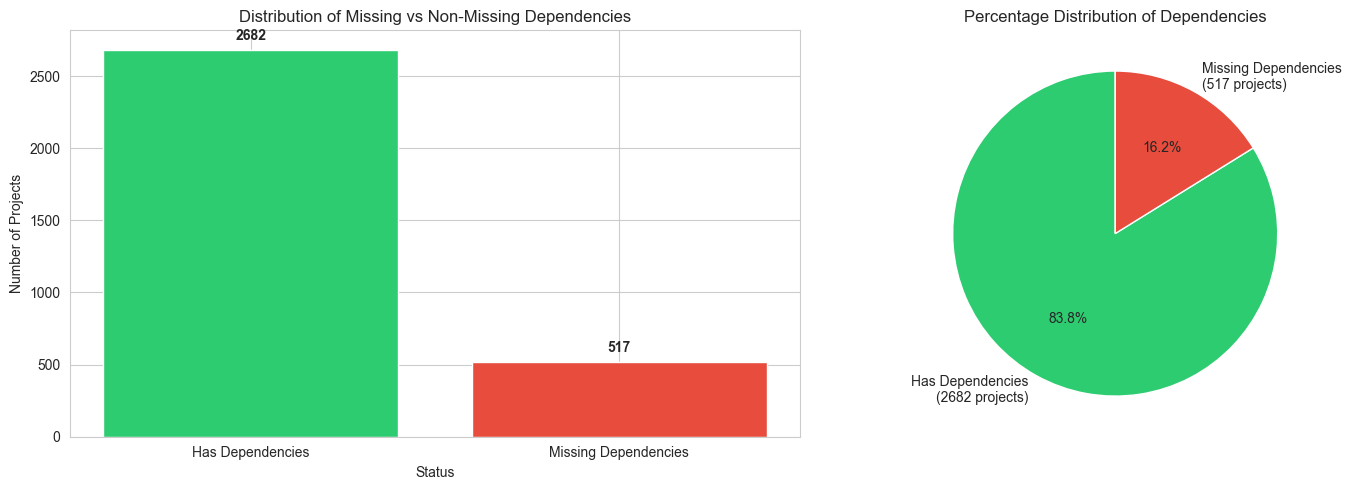

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# 1. Count of Missing vs Non-Missing Dependencies
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart showing missing vs non-missing
dependency_counts = df['dependecies_found'].isnull().value_counts()
axes[0].bar(['Has Dependencies', 'Missing Dependencies'], 
            [dependency_counts[False], dependency_counts[True]], 
            color=['#2ecc71', '#e74c3c'])
axes[0].set_ylabel('Number of Projects')
axes[0].set_title('Distribution of Missing vs Non-Missing Dependencies')
axes[0].set_xlabel('Status')

# Add value labels on bars
for i, v in enumerate([dependency_counts[False], dependency_counts[True]]):
    axes[0].text(i, v + 50, str(v), ha='center', va='bottom', fontweight='bold')

# Pie chart
colors = ['#2ecc71', '#e74c3c']
labels = [f'Has Dependencies\n({dependency_counts[False]} projects)', 
          f'Missing Dependencies\n({dependency_counts[True]} projects)']
axes[1].pie([dependency_counts[False], dependency_counts[True]], 
            labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Percentage Distribution of Dependencies')

plt.tight_layout()
plt.show()

In [ ]:
# 2. Examine the actual content of the dependecies_found column
print("Sample values from 'dependecies_found' column:")
print("-" * 50)
print(df['dependecies_found'].head(20))
print("\n" + "=" * 50)
print(f"\nData type: {df['dependecies_found'].dtype}")
print(f"Unique values count: {df['dependecies_found'].nunique()}")

Sample values from 'dependecies_found' column:
--------------------------------------------------
0     ["contique", "einsumt", "h5py", "imageio", "ja...
1                                                    []
2     ["data_slicer", "h5py", "igor2", "ipywidgets",...
3     ["Deprecated", "PICOS", "control", "cvxopt", "...
4     ["click", "docstring-parser", "filelock", "jso...
5                                                   NaN
6     ["Pillow", "PyYaml", "bagit", "build", "cffcon...
7                                                    []
8                                                    []
9                                                    []
10    ["bidict", "black", "cairosvg", "jsonpickle", ...
11    ["autoflake", "beartype", "black", "build", "p...
12    ["affine", "alabaster", "antimeridian", "anyio...
13                                                   []
14                                                   []
15    ["ipython", "jupyter", "matplotlib", "numba", ...
16    

<Figure size 1400x600 with 0 Axes>

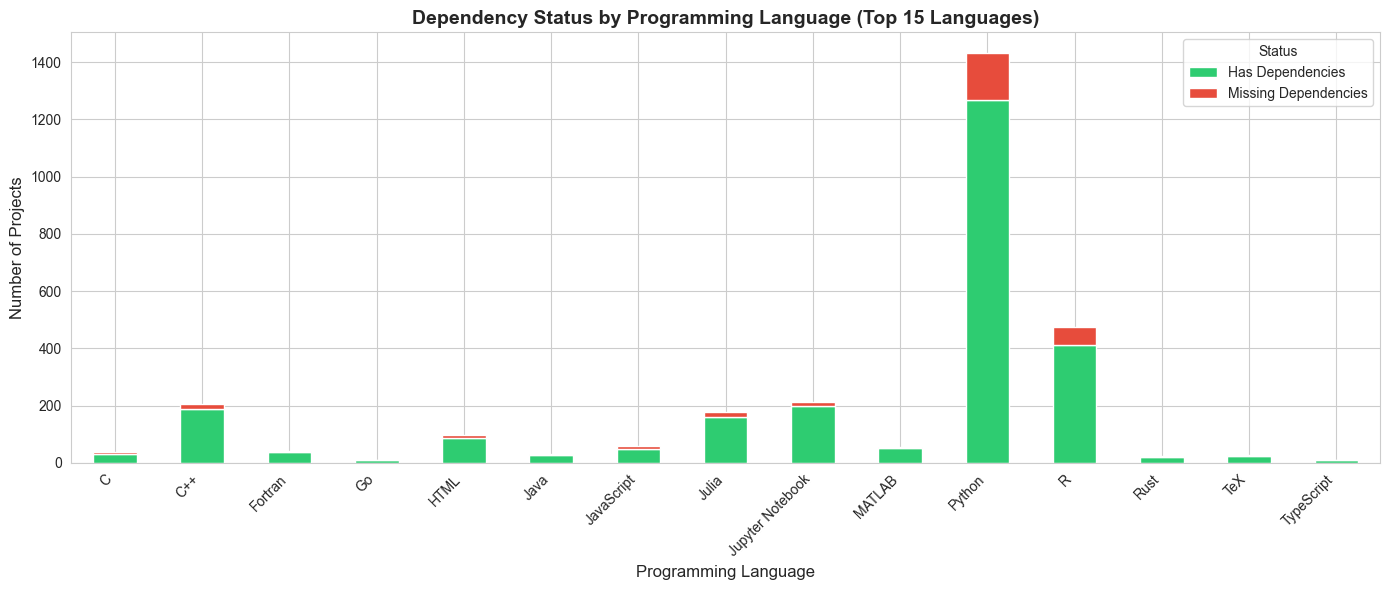

In [ ]:
# 3. Dependencies by Programming Language
plt.figure(figsize=(14, 6))

# Create a dataframe with language and dependency status
lang_dep = df.groupby(['Language', df['dependecies_found'].isnull()]).size().unstack(fill_value=0)
lang_dep.columns = ['Has Dependencies', 'Missing Dependencies']

# Filter to top 15 languages by total projects
top_languages = df['Language'].value_counts().head(15).index
lang_dep_top = lang_dep.loc[lang_dep.index.isin(top_languages)]

# Create stacked bar chart
lang_dep_top.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], figsize=(14, 6))
plt.title('Dependency Status by Programming Language (Top 15 Languages)', fontsize=14, fontweight='bold')
plt.xlabel('Programming Language', fontsize=12)
plt.ylabel('Number of Projects', fontsize=12)
plt.legend(title='Status', loc='upper right')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [10]:
import pandas as pd
import ast

# Load the dataset
df = pd.read_csv('joss_all_language_depends.csv')

# Define dependency patterns for each category
dependency_categories = {
    'Modeling_Simulation': {
        'keywords': ['numpy', 'scipy', 'simpy', 'mesa', 'networkx', 'pyomo', 'fenics', 
                     'openfoam', 'lammps', 'gromacs', 'abaqus', 'ansys', 'comsol',
                     'simulation', 'simulator', 'model', 'finite element', 'monte carlo'],
        'description_keywords': ['simulation', 'modeling', 'model', 'finite element', 
                                'monte carlo', 'agent-based']
    },
    
    'Data_Analytics_ML': {
        'keywords': ['pandas', 'matplotlib', 'seaborn', 'plotly', 'scikit-learn', 
                     'tensorflow', 'pytorch', 'keras', 'xgboost', 'statsmodels',
                     'prophet', 'nltk', 'spacy', 'transformers', 'jax'],
        'description_keywords': ['machine learning', 'deep learning', 'data analysis',
                                'neural network', 'classification', 'regression', 'clustering']
    },
    
    'Instrumentation_Hardware': {
        'keywords': ['pyvisa', 'pyserial', 'nidaqmx', 'opencv', 'pillow', 'imageio',
                     'pyqt', 'tkinter', 'pyside', 'micropython', 'arduino', 'raspberry',
                     'labview', 'hardware', 'instrument', 'sensor'],
        'description_keywords': ['hardware', 'instrument', 'sensor', 'measurement', 
                                'control', 'acquisition', 'microscopy', 'imaging']
    },
    
    'Research_Infrastructure': {
        'keywords': ['airflow', 'dask', 'luigi', 'prefect', 'celery', 'redis', 
                     'sqlalchemy', 'alembic', 'flask', 'django', 'fastapi',
                     'docker', 'kubernetes', 'gitlab', 'github', 'jupyterhub'],
        'description_keywords': ['workflow', 'pipeline', 'infrastructure', 'database',
                                'deployment', 'automation', 'orchestration', 'platform']
    },
    
    'Scientific_Computing': {
        'keywords': ['numba', 'cython', 'cupy', 'cuda', 'opencl', 'mpi4py', 
                     'petsc', 'trilinos', 'eigen', 'blas', 'lapack', 'fftw',
                     'hdf5', 'netcdf4', 'zarr'],
        'description_keywords': ['high performance', 'parallel', 'gpu', 'hpc',
                                'distributed', 'computational']
    },
    
    'Domain_Specific': {
        'Bioinformatics': ['biopython', 'bioconductor', 'pysam', 'bedtools', 'blast'],
        'Geospatial': ['geopandas', 'rasterio', 'shapely', 'gdal', 'cartopy', 'folium'],
        'Astronomy': ['astropy', 'galpy', 'sunpy', 'pyephem'],
        'Chemistry': ['rdkit', 'openbabel', 'ase', 'pymatgen', 'mdanalysis'],
        'Physics': ['qutip', 'kwant', 'pytket', 'cirq', 'qiskit']
    }
}

def categorize_project(row):
    """
    Categorize a project based on dependencies and description
    Returns a dictionary with category flags
    """
    categories = {
        'is_modeling_simulation': False,
        'is_data_analytics_ml': False,
        'is_instrumentation_hardware': False,
        'is_research_infrastructure': False,
        'is_scientific_computing': False,
        'domain_specific': []
    }
    
    # Parse dependencies
    deps = []
    if pd.notna(row['dependecies_found']):
        try:
            deps = ast.literal_eval(row['dependecies_found'])
            if not isinstance(deps, list):
                deps = []
        except:
            deps = []
    
    # Convert to lowercase for matching
    deps_lower = [str(d).lower() for d in deps]
    
    # Get description
    description = str(row.get('description', '')).lower() if 'description' in row else ''
    
    # Check each category
    for dep in deps_lower:
        # Modeling/Simulation
        if any(keyword in dep for keyword in dependency_categories['Modeling_Simulation']['keywords']):
            categories['is_modeling_simulation'] = True
        
        # Data Analytics/ML
        if any(keyword in dep for keyword in dependency_categories['Data_Analytics_ML']['keywords']):
            categories['is_data_analytics_ml'] = True
        
        # Instrumentation/Hardware
        if any(keyword in dep for keyword in dependency_categories['Instrumentation_Hardware']['keywords']):
            categories['is_instrumentation_hardware'] = True
        
        # Research Infrastructure
        if any(keyword in dep for keyword in dependency_categories['Research_Infrastructure']['keywords']):
            categories['is_research_infrastructure'] = True
        
        # Scientific Computing
        if any(keyword in dep for keyword in dependency_categories['Scientific_Computing']['keywords']):
            categories['is_scientific_computing'] = True
        
        # Domain Specific
        for domain, keywords in dependency_categories['Domain_Specific'].items():
            if any(keyword in dep for keyword in keywords):
                if domain not in categories['domain_specific']:
                    categories['domain_specific'].append(domain)
    
    # Also check description
    for keyword in dependency_categories['Modeling_Simulation']['description_keywords']:
        if keyword in description:
            categories['is_modeling_simulation'] = True
            break
    
    for keyword in dependency_categories['Data_Analytics_ML']['description_keywords']:
        if keyword in description:
            categories['is_data_analytics_ml'] = True
            break
    
    # Convert domain_specific list to string
    categories['domain_specific'] = ','.join(categories['domain_specific']) if categories['domain_specific'] else ''
    
    return pd.Series(categories)

# Apply categorization
print("Categorizing projects...")
category_df = df.apply(categorize_project, axis=1)

# Add categories to original dataframe
for col in category_df.columns:
    df[col] = category_df[col]

# Save the updated dataframe
df.to_csv('joss_all_language_depends_categorized.csv', index=False)
print("Categorization complete! Saved to 'joss_all_language_depends_categorized.csv'")

# Show statistics
print("\n=== Categorization Statistics ===")
print(f"Total projects: {len(df)}")
print(f"Modeling/Simulation: {df['is_modeling_simulation'].sum()} ({df['is_modeling_simulation'].sum()/len(df)*100:.1f}%)")
print(f"Data Analytics/ML: {df['is_data_analytics_ml'].sum()} ({df['is_data_analytics_ml'].sum()/len(df)*100:.1f}%)")
print(f"Instrumentation/Hardware: {df['is_instrumentation_hardware'].sum()} ({df['is_instrumentation_hardware'].sum()/len(df)*100:.1f}%)")
print(f"Research Infrastructure: {df['is_research_infrastructure'].sum()} ({df['is_research_infrastructure'].sum()/len(df)*100:.1f}%)")
print(f"Scientific Computing: {df['is_scientific_computing'].sum()} ({df['is_scientific_computing'].sum()/len(df)*100:.1f}%)")

# Projects with multiple categories
multiple_categories = df[
    (df['is_modeling_simulation'].astype(int) + 
     df['is_data_analytics_ml'].astype(int) + 
     df['is_instrumentation_hardware'].astype(int) + 
     df['is_research_infrastructure'].astype(int) + 
     df['is_scientific_computing'].astype(int)) > 1
]
print(f"\nProjects with multiple categories: {len(multiple_categories)} ({len(multiple_categories)/len(df)*100:.1f}%)")

Categorizing projects...
Categorization complete! Saved to 'joss_all_language_depends_categorized.csv'

=== Categorization Statistics ===
Total projects: 3199
Modeling/Simulation: 906 (28.3%)
Data Analytics/ML: 827 (25.9%)
Instrumentation/Hardware: 248 (7.8%)
Research Infrastructure: 125 (3.9%)
Scientific Computing: 308 (9.6%)

Projects with multiple categories: 823 (25.7%)
Categorization complete! Saved to 'joss_all_language_depends_categorized.csv'

=== Categorization Statistics ===
Total projects: 3199
Modeling/Simulation: 906 (28.3%)
Data Analytics/ML: 827 (25.9%)
Instrumentation/Hardware: 248 (7.8%)
Research Infrastructure: 125 (3.9%)
Scientific Computing: 308 (9.6%)

Projects with multiple categories: 823 (25.7%)


In [12]:
# First, let's check what columns we have after categorization
print("Available columns in the dataframe:")
print(df.columns.tolist())
print(f"\nDataframe shape: {df.shape}")

Available columns in the dataframe:
['status', 'paper_url', 'issue_url', 'doi', 'joss_id', 'title', 'html_url', 'Repository Name', 'Full Name', 'Description', 'Stars', 'Forks', 'Issues', 'Watchers', 'Language', 'License', 'Created Date', 'Updated Date', 'Pushed Date', 'Default Branch', 'Size', 'Contributors', 'Number of Contributors', 'Total Downloads', 'requirements_defined', 'dependecies_found', 'is_modeling_simulation', 'is_data_analytics_ml', 'is_instrumentation_hardware', 'is_research_infrastructure', 'is_scientific_computing', 'domain_specific']

Dataframe shape: (3199, 32)


In [20]:
%pip install sklearn

Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-